# Chargement des bibliothèques

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from scipy.cluster.hierarchy import linkage, dendrogram

# Chargement des données

In [2]:
food_path = "D:\\openclassrooms\\Projet 9\\DAN-P9-data\\DAN-P9-data\\DisponibiliteAlimentaire_2017.csv"
pop_path = "D:\\openclassrooms\\Projet 9\\DAN-P9-data\\DAN-P9-data\\Population_2000_2018.csv"

food = pd.read_csv(food_path, sep=",", encoding="utf-8")
pop = pd.read_csv(pop_path, sep=",", encoding="utf-8")

print("Shapes :", food.shape, pop.shape)
display(food.head(3))
display(pop.head(3))

Shapes : (176600, 14) (4411, 15)


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole
0,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5511,Production,2511,Blé et produits,2017,2017,Milliers de tonnes,4281.0,S,Données standardisées
1,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5611,Importations - Quantité,2511,Blé et produits,2017,2017,Milliers de tonnes,2302.0,S,Données standardisées
2,FBS,Nouveaux Bilans Alimentaire,2,Afghanistan,5072,Variation de stock,2511,Blé et produits,2017,2017,Milliers de tonnes,-119.0,S,Données standardisées


,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN


In [3]:
food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176600 entries, 0 to 176599
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Code Domaine            176600 non-null  object 
 1   Domaine                 176600 non-null  object 
 2   Code zone               176600 non-null  int64  
 3   Zone                    176600 non-null  object 
 4   Code Élément            176600 non-null  int64  
 5   Élément                 176600 non-null  object 
 6   Code Produit            176600 non-null  int64  
 7   Produit                 176600 non-null  object 
 8   Code année              176600 non-null  int64  
 9   Année                   176600 non-null  int64  
 10  Unité                   176600 non-null  object 
 11  Valeur                  176600 non-null  float64
 12  Symbole                 176600 non-null  object 
 13  Description du Symbole  176600 non-null  object 
dtypes: float64(1), int64

### Modification des colonnes en type objet 

In [4]:
food['Code zone'] = food['Code zone'].astype('object')
food['Code Élément'] = food['Code Élément'].astype('object')
food['Code Produit'] = food['Code Produit'].astype('object')
food['Code année'] = food['Code année'].astype('object')
food['Année'] = food['Année'].astype('object')

In [5]:
food.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176600 entries, 0 to 176599
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Code Domaine            176600 non-null  object 
 1   Domaine                 176600 non-null  object 
 2   Code zone               176600 non-null  object 
 3   Zone                    176600 non-null  object 
 4   Code Élément            176600 non-null  object 
 5   Élément                 176600 non-null  object 
 6   Code Produit            176600 non-null  object 
 7   Produit                 176600 non-null  object 
 8   Code année              176600 non-null  object 
 9   Année                   176600 non-null  object 
 10  Unité                   176600 non-null  object 
 11  Valeur                  176600 non-null  float64
 12  Symbole                 176600 non-null  object 
 13  Description du Symbole  176600 non-null  object 
dtypes: float64(1), objec

In [6]:
food.describe()

,Valeur
count,176600.000000
mean,210.554918
std,4762.047787
min,-10388.000000
25%,0.000000
50%,0.120000
75%,8.462500
max,758548.000000


In [7]:
food['Élément'].unique()

array(['Production', 'Importations - Quantité', 'Variation de stock',
       'Exportations - Quantité', 'Disponibilité intérieure',
       'Aliments pour animaux', 'Semences', 'Pertes', 'Résidus',
       'Nourriture',
       'Disponibilité alimentaire en quantité (kg/personne/an)',
       'Disponibilité alimentaire (Kcal/personne/jour)',
       'Disponibilité de protéines en quantité (g/personne/jour)',
       'Disponibilité de matière grasse en quantité (g/personne/jour)',
       'Traitement', 'Autres utilisations (non alimentaire)',
       'Alimentation pour touristes'], dtype=object)

In [8]:
food['Produit'].unique()

array(['Blé et produits', 'Riz et produits', 'Orge et produits',
       'Maïs et produits', 'Seigle et produits', 'Avoine',
       'Millet et produits', 'Sorgho et produits', 'Céréales, Autres',
       'Pommes de Terre et produits', 'Ignames', 'Racines nda',
       'Sucre, canne', 'Sucre, betterave', 'Sucre Eq Brut',
       'Edulcorants Autres', 'Miel', 'Haricots', 'Pois',
       'Légumineuses Autres et produits', 'Noix et produits', 'Soja',
       'Arachides Decortiquees', 'Graines de tournesol',
       'Graines Colza/Moutarde', 'Graines de coton', 'Coco (Incl Coprah)',
       'Sésame', 'Olives', 'Plantes Oleiferes, Autre', 'Huile de Soja',
       "Huile d'Arachide", 'Huile de Tournesol',
       'Huile de Colza&Moutarde', 'Huile Graines de Coton',
       'Huile de Palmistes', 'Huile de Palme', 'Huile de Coco',
       'Huile de Sésame', "Huile d'Olive", 'Huile de Son de Riz',
       'Huile de Germe de Maïs', 'Huil Plantes Oleif Autr',
       'Tomates et produits', 'Oignons', 'Légumes, 

### Filtrer sur Viande de Volailles

In [9]:
food['Produit'] == 'Viande de Volailles'

0         False
1         False
2         False
3         False
4         False
          ...  
176595    False
176596    False
176597    False
176598    False
176599    False
Name: Produit, Length: 176600, dtype: bool

In [10]:
Volaille = food[food['Produit']=='Viande de Volailles']

### On fait pivoter ces éléments pour pouvoir les traiter 

In [11]:
## on choisit zone car ce sojnt les pays qui nous interessent
Volaille_bis = Volaille.set_index("Zone")
Volaille_bis = Volaille_bis.pivot(columns="Élément", values ="Valeur")
Volaille_bis.head(10)

Élément,Alimentation pour touristes,Aliments pour animaux,Autres utilisations (non alimentaire),Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Résidus,Semences,Traitement,Variation de stock
Zone,,,,,,,,,,,,,,,,,
Afghanistan,NaN,NaN,NaN,5.0,1.53,0.33,0.54,57.0,NaN,29.0,55.0,2.0,28.0,0.0,NaN,NaN,0.0
Afrique du Sud,0.0,NaN,NaN,143.0,35.69,9.25,14.11,2118.0,63.0,514.0,2035.0,83.0,1667.0,0.0,NaN,NaN,-0.0
Albanie,NaN,NaN,NaN,85.0,16.36,6.45,6.26,47.0,0.0,38.0,47.0,NaN,13.0,0.0,NaN,NaN,4.0
Algérie,0.0,NaN,NaN,22.0,6.38,1.50,1.97,277.0,0.0,2.0,264.0,13.0,275.0,0.0,NaN,NaN,0.0
Allemagne,NaN,NaN,NaN,71.0,19.47,4.16,7.96,1739.0,646.0,842.0,1609.0,NaN,1514.0,-38.0,NaN,167.0,-29.0
Angola,0.0,NaN,NaN,35.0,10.56,2.22,3.60,319.0,0.0,277.0,315.0,2.0,42.0,0.0,NaN,2.0,-0.0
Antigua-et-Barbuda,2.0,NaN,0.0,233.0,54.10,17.55,17.77,7.0,0.0,7.0,5.0,NaN,0.0,0.0,NaN,NaN,0.0
Arabie saoudite,NaN,NaN,NaN,151.0,43.36,9.38,15.57,1435.0,10.0,722.0,1435.0,NaN,616.0,0.0,NaN,NaN,-108.0
Argentine,NaN,NaN,NaN,182.0,42.24,13.84,13.53,1962.0,207.0,8.0,1856.0,106.0,2161.0,0.0,NaN,NaN,0.0


### Conversion de la disponibilité alimentaire est en milliers de tonnne

In [12]:
Volaille_bis['Disponibilité intérieure'] = Volaille_bis['Disponibilité intérieure']*1000
Volaille_bis['Exportations - Quantité'] = Volaille_bis['Exportations - Quantité']*1000

In [13]:
Volaille_final = Volaille_bis.reset_index()

In [14]:
Volaille_final.head()

Élément,Zone,Alimentation pour touristes,Aliments pour animaux,Autres utilisations (non alimentaire),Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Nourriture,Pertes,Production,Résidus,Semences,Traitement,Variation de stock
0,Afghanistan,NaN,NaN,NaN,5.0,1.53,0.33,0.54,57000.0,NaN,29.0,55.0,2.0,28.0,0.0,NaN,NaN,0.0
1,Afrique du Sud,0.0,NaN,NaN,143.0,35.69,9.25,14.11,2118000.0,63000.0,514.0,2035.0,83.0,1667.0,0.0,NaN,NaN,-0.0
2,Albanie,NaN,NaN,NaN,85.0,16.36,6.45,6.26,47000.0,0.0,38.0,47.0,NaN,13.0,0.0,NaN,NaN,4.0
3,Algérie,0.0,NaN,NaN,22.0,6.38,1.50,1.97,277000.0,0.0,2.0,264.0,13.0,275.0,0.0,NaN,NaN,0.0
4,Allemagne,NaN,NaN,NaN,71.0,19.47,4.16,7.96,1739000.0,646000.0,842.0,1609.0,NaN,1514.0,-38.0,NaN,167.0,-29.0


In [15]:
pop.head()

,Code Domaine,Domaine,Code zone,Zone,Code Élément,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,OA,Séries temporelles annuelles,2,Afghanistan,511,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN


In [16]:
tableau_final = pd.merge(Volaille_final, pop, on ='Zone', how = 'left')

In [17]:
tableau_final.head()

,Zone,Alimentation pour touristes,Aliments pour animaux,Autres utilisations (non alimentaire),Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,...,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,Afghanistan,NaN,NaN,NaN,5.0,1.53,0.33,0.54,57000.0,NaN,...,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779.953,X,Sources internationales sûres,NaN
1,Afghanistan,NaN,NaN,NaN,5.0,1.53,0.33,0.54,57000.0,NaN,...,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606.988,X,Sources internationales sûres,NaN
2,Afghanistan,NaN,NaN,NaN,5.0,1.53,0.33,0.54,57000.0,NaN,...,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600.770,X,Sources internationales sûres,NaN
3,Afghanistan,NaN,NaN,NaN,5.0,1.53,0.33,0.54,57000.0,NaN,...,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680.871,X,Sources internationales sûres,NaN
4,Afghanistan,NaN,NaN,NaN,5.0,1.53,0.33,0.54,57000.0,NaN,...,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726.684,X,Sources internationales sûres,NaN


In [18]:
tableau_final['Valeur'] = tableau_final['Valeur']*1000
tableau_final['Disponibilité alimentaire en quantité (kg/personne/an)'] = tableau_final['Disponibilité alimentaire en quantité (kg/personne/an)']*(tableau_final['Valeur'])
tableau_final['Disponibilité alimentaire (Kcal/personne/jour)'] = (tableau_final['Disponibilité alimentaire (Kcal/personne/jour)']*(tableau_final['Valeur']))*365
tableau_final['Disponibilité de matière grasse en quantité (g/personne/jour)'] = (tableau_final['Disponibilité de matière grasse en quantité (g/personne/jour)']*(tableau_final['Valeur']))*365
tableau_final['Disponibilité de protéines en quantité (g/personne/jour)'] = (tableau_final['Disponibilité de protéines en quantité (g/personne/jour)']*(tableau_final['Valeur']))*365

In [19]:
tableau_final.head()

,Zone,Alimentation pour touristes,Aliments pour animaux,Autres utilisations (non alimentaire),Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,...,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
0,Afghanistan,NaN,NaN,NaN,3.792341e+10,31793328.09,2.502945e+09,4.095729e+09,57000.0,NaN,...,Population totale,3010,Population-Estimations,2000,2000,1000 personnes,20779953.0,X,Sources internationales sûres,NaN
1,Afghanistan,NaN,NaN,NaN,3.943275e+10,33058691.64,2.602562e+09,4.258737e+09,57000.0,NaN,...,Population totale,3010,Population-Estimations,2001,2001,1000 personnes,21606988.0,X,Sources internationales sûres,NaN
2,Afghanistan,NaN,NaN,NaN,4.124641e+10,34579178.10,2.722263e+09,4.454612e+09,57000.0,NaN,...,Population totale,3010,Population-Estimations,2002,2002,1000 personnes,22600770.0,X,Sources internationales sûres,NaN
3,Afghanistan,NaN,NaN,NaN,4.321759e+10,36231732.63,2.852361e+09,4.667500e+09,57000.0,NaN,...,Population totale,3010,Population-Estimations,2003,2003,1000 personnes,23680871.0,X,Sources internationales sûres,NaN
4,Afghanistan,NaN,NaN,NaN,4.512620e+10,37831826.52,2.978329e+09,4.873629e+09,57000.0,NaN,...,Population totale,3010,Population-Estimations,2004,2004,1000 personnes,24726684.0,X,Sources internationales sûres,NaN


### On filtre sur l'année 2017

In [20]:
tableau_final = tableau_final[(tableau_final['Année'] == 2017)]

In [21]:
tableau_final.head()

,Zone,Alimentation pour touristes,Aliments pour animaux,Autres utilisations (non alimentaire),Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,...,Élément,Code Produit,Produit,Code année,Année,Unité,Valeur,Symbole,Description du Symbole,Note
17,Afghanistan,NaN,NaN,NaN,6.624041e+10,5.553305e+07,4.371867e+09,7.153964e+09,57000.0,NaN,...,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,36296113.0,X,Sources internationales sûres,NaN
36,Afrique du Sud,0.0,NaN,NaN,2.975624e+12,2.034678e+09,1.924792e+11,2.936088e+11,2118000.0,63000.0,...,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,57009756.0,X,Sources internationales sûres,NaN
55,Albanie,NaN,NaN,NaN,8.948134e+10,4.718500e+07,6.790055e+09,6.590038e+09,47000.0,0.0,...,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,2884169.0,X,Sources internationales sûres,NaN
74,Algérie,0.0,NaN,NaN,3.323552e+11,2.640630e+08,2.266058e+10,2.976090e+10,277000.0,0.0,...,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,41389189.0,X,Sources internationales sûres,NaN
93,Allemagne,NaN,NaN,NaN,2.142093e+12,1.609359e+09,1.255085e+11,2.401557e+11,1739000.0,646000.0,...,Population totale,3010,Population-Estimations,2017,2017,1000 personnes,82658409.0,X,Sources internationales sûres,NaN


### Sélection des colonnes les plus pertinentes

In [22]:
 for idx,column in enumerate(tableau_final.columns):
        print(idx,column)

0 Zone
1 Alimentation pour touristes
2 Aliments pour animaux
3 Autres utilisations (non alimentaire)
4 Disponibilité alimentaire (Kcal/personne/jour)
5 Disponibilité alimentaire en quantité (kg/personne/an)
6 Disponibilité de matière grasse en quantité (g/personne/jour)
7 Disponibilité de protéines en quantité (g/personne/jour)
8 Disponibilité intérieure
9 Exportations - Quantité
10 Importations - Quantité
11 Nourriture
12 Pertes
13 Production
14 Résidus
15 Semences
16 Traitement
17 Variation de stock
18 Code Domaine
19 Domaine
20 Code zone
21 Code Élément
22 Élément
23 Code Produit
24 Produit
25 Code année
26 Année
27 Unité
28 Valeur
29 Symbole
30 Description du Symbole
31 Note


In [23]:
df_final = tableau_final.iloc[:,[0,4,5,6,7,8,9,10,28] ]
df_final.head()

,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité de matière grasse en quantité (g/personne/jour),Disponibilité de protéines en quantité (g/personne/jour),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Valeur
17,Afghanistan,6.624041e+10,5.553305e+07,4.371867e+09,7.153964e+09,57000.0,NaN,29.0,36296113.0
36,Afrique du Sud,2.975624e+12,2.034678e+09,1.924792e+11,2.936088e+11,2118000.0,63000.0,514.0,57009756.0
55,Albanie,8.948134e+10,4.718500e+07,6.790055e+09,6.590038e+09,47000.0,0.0,38.0,2884169.0
74,Algérie,3.323552e+11,2.640630e+08,2.266058e+10,2.976090e+10,277000.0,0.0,2.0,41389189.0
93,Allemagne,2.142093e+12,1.609359e+09,1.255085e+11,2.401557e+11,1739000.0,646000.0,842.0,82658409.0


In [24]:
df_final = df_final.rename(columns ={'Valeur' : 'Population'})
df_final = df_final.rename(columns ={'Disponibilité alimentaire (Kcal/personne/jour)' : 'Disponibilité alimentaire','Disponibilité alimentaire en quantité (kg/personne/an)':'Disponibilité alimentaire en quantité ','Disponibilité de matière grasse en quantité (g/personne/jour)':'Disponibilité de matière grasse en quantité ','Disponibilité de protéines en quantité (g/personne/jour)':'Disponibilité de protéines en quantité '})
df_final = df_final.replace('NaN', 0)
df_final = df_final.fillna(0)
df_final.head()

,Zone,Disponibilité alimentaire,Disponibilité alimentaire en quantité,Disponibilité de matière grasse en quantité,Disponibilité de protéines en quantité,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Population
17,Afghanistan,6.624041e+10,5.553305e+07,4.371867e+09,7.153964e+09,57000.0,0.0,29.0,36296113.0
36,Afrique du Sud,2.975624e+12,2.034678e+09,1.924792e+11,2.936088e+11,2118000.0,63000.0,514.0,57009756.0
55,Albanie,8.948134e+10,4.718500e+07,6.790055e+09,6.590038e+09,47000.0,0.0,38.0,2884169.0
74,Algérie,3.323552e+11,2.640630e+08,2.266058e+10,2.976090e+10,277000.0,0.0,2.0,41389189.0
93,Allemagne,2.142093e+12,1.609359e+09,1.255085e+11,2.401557e+11,1739000.0,646000.0,842.0,82658409.0


In [25]:
df_final.describe()

,Disponibilité alimentaire,Disponibilité alimentaire en quantité,Disponibilité de matière grasse en quantité,Disponibilité de protéines en quantité,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Population
count,1.720000e+02,1.720000e+02,1.720000e+02,1.720000e+02,1.720000e+02,1.720000e+02,172.000000,1.720000e+02
mean,9.281931e+11,6.502631e+08,6.423216e+10,8.211543e+10,6.795988e+05,1.037500e+05,88.488372,4.284175e+07
std,3.329214e+12,2.125178e+09,2.472756e+11,2.631800e+11,2.175613e+06,4.580661e+05,185.824620,1.530637e+08
min,0.000000e+00,1.961133e+06,1.587337e+08,2.426358e+08,0.000000e+00,0.000000e+00,0.000000,5.204500e+04
25%,3.626569e+10,2.920230e+07,2.361724e+09,3.498012e+09,2.875000e+04,0.000000e+00,3.000000,2.874480e+06
50%,1.219858e+11,9.460390e+07,7.080734e+09,1.125110e+10,9.800000e+04,0.000000e+00,16.000000,9.757833e+06
75%,4.723554e+11,3.537556e+08,3.092863e+10,4.698269e+10,3.607500e+05,1.200000e+04,79.750000,3.013874e+07
max,3.060170e+13,1.810072e+10,2.422203e+12,2.364813e+12,1.826600e+07,4.223000e+06,1069.000000,1.421022e+09


In [48]:
# Exporter le dataframe nettoyé vers un fichier CSV
df_final.to_csv('donnees_dffinal.csv', index=False)

print("Le fichier CSV a été généré avec succès !")

Le fichier CSV a été généré avec succès !


## Retrait des données non numériques du tableau

In [26]:
df_num = df_final.iloc[:,[1,2,3,4,5,6,7]]
df_num.head()

,Disponibilité alimentaire,Disponibilité alimentaire en quantité,Disponibilité de matière grasse en quantité,Disponibilité de protéines en quantité,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité
17,6.624041e+10,5.553305e+07,4.371867e+09,7.153964e+09,57000.0,0.0,29.0
36,2.975624e+12,2.034678e+09,1.924792e+11,2.936088e+11,2118000.0,63000.0,514.0
55,8.948134e+10,4.718500e+07,6.790055e+09,6.590038e+09,47000.0,0.0,38.0
74,3.323552e+11,2.640630e+08,2.266058e+10,2.976090e+10,277000.0,0.0,2.0
93,2.142093e+12,1.609359e+09,1.255085e+11,2.401557e+11,1739000.0,646000.0,842.0


In [47]:
# Exporter le dataframe nettoyé vers un fichier CSV
df_num.to_csv('donnees_nettoyees.csv', index=False)

print("Le fichier CSV a été généré avec succès !")

Le fichier CSV a été généré avec succès !


# CAH, Kmeans

### Etape 1 : Préparation des données

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import scipy.cluster.hierarchy as sch

# 1. Gestion de l'index
# On met la 'Zone' (pays) en index pour qu'elle ne soit pas considérée comme une variable mathématique
# mais qu'on puisse identifier les pays à la fin.
data_clustering = df_final.set_index('Zone')

# 2. Centrage et Réduction (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_clustering)

# On remet ça dans un DataFrame pour le confort de lecture (optionnel mais pratique)
df_scaled = pd.DataFrame(X_scaled, columns=data_clustering.columns, index=data_clustering.index)

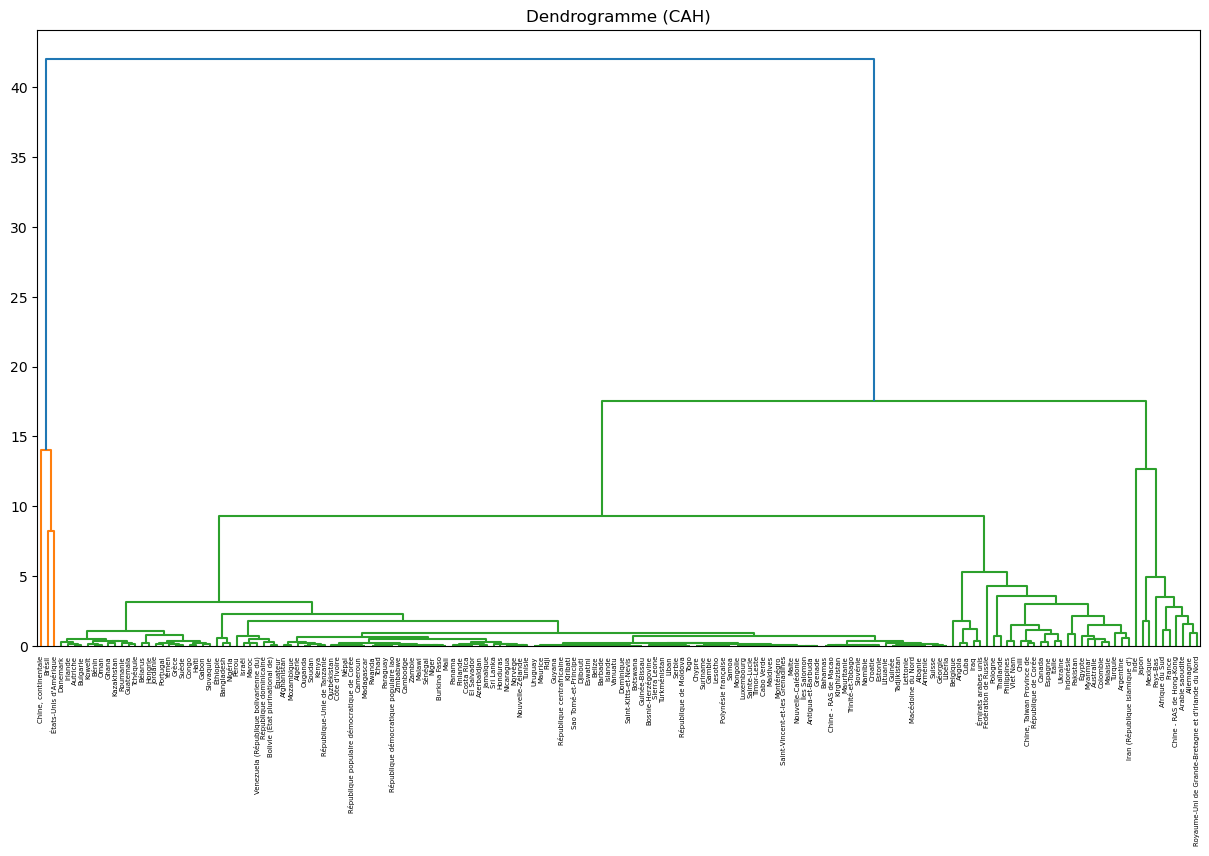

In [28]:
# Configuration de la taille du graphique
plt.figure(figsize=(15, 8))
plt.title("Dendrogramme (CAH)")

# Génération de la matrice de liens (méthode de Ward pour minimiser la variance intra-classe)
Z = sch.linkage(X_scaled, method='ward')

# Affichage du dendrogramme
dendrogram = sch.dendrogram(Z, labels=df_scaled.index, leaf_rotation=90)
plt.show()

# --- DÉCISION DU NOMBRE DE CLUSTERS ---
# Regarde le dendrogramme. Si tu coupes l'arbre horizontalement là où les branches sont les plus longues,
# combien de lignes verticales coupes-tu ? Disons que c'est 4 ou 5 pour cet exemple.
n_clusters_cah = 5  # À ajuster selon ta lecture du graphique

In [29]:
from sklearn.cluster import KMeans

# Choisissons un nombre de clusters (k). Idéalement, le même que celui identifié par la CAH.
k = 5 

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# On ajoute les labels des clusters à notre dataframe original pour l'analyse
df_final['Cluster_KMeans'] = kmeans.labels_

# Vérifions combien de pays il y a par cluster
print(df_final['Cluster_KMeans'].value_counts())

2    156
0     12
3      2
1      1
4      1
Name: Cluster_KMeans, dtype: int64


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


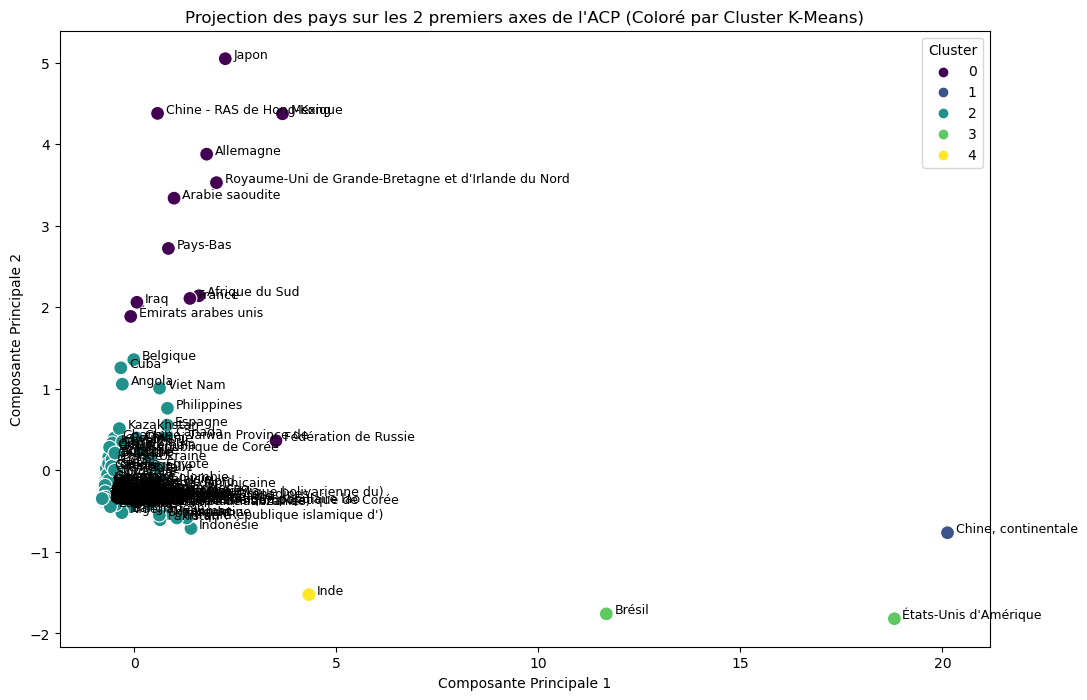

In [30]:
# 1. Calcul de l'ACP
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

# Création d'un DataFrame pour l'affichage
df_pca = pd.DataFrame(data=components, columns=['PC1', 'PC2'], index=data_clustering.index)
df_pca['Cluster'] = kmeans.labels_ # On colore selon le K-Means

# 2. Visualisation
plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=100)

# Ajouter les noms des pays (optionnel, attention si trop de pays ça devient illisible)
for i in range(df_pca.shape[0]):
    plt.text(df_pca.PC1[i]+0.2, df_pca.PC2[i], df_pca.index[i], fontsize=9)

plt.title("Projection des pays sur les 2 premiers axes de l'ACP (Coloré par Cluster K-Means)")
plt.xlabel("Composante Principale 1")
plt.ylabel("Composante Principale 2")
plt.show()

In [31]:
# Récupérer les clusters de la CAH (en coupant l'arbre pour avoir k groupes)
from scipy.cluster.hierarchy import fcluster
clusters_cah = fcluster(Z, t=k, criterion='maxclust')

# Créer un tableau de contingence (Cross-tabulation)
# Cela montre si les pays classés "1" par K-Means sont aussi "1" par CAH
comparison = pd.crosstab(clusters_cah, kmeans.labels_, rownames=['CAH'], colnames=['KMeans'])
print("Matrice de confusion entre CAH et K-Means :")
print(comparison)

Matrice de confusion entre CAH et K-Means :
KMeans  0  1    2  3  4
CAH                    
1       0  0    0  2  0
2       0  1    0  0  0
3       3  0  156  0  0
4       9  0    0  0  0
5       0  0    0  0  1


C:\Users\lapoi\AppData\Local\Temp\ipykernel_21680\3530721413.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  centroid_analysis = df_final.groupby('Cluster_KMeans').mean()


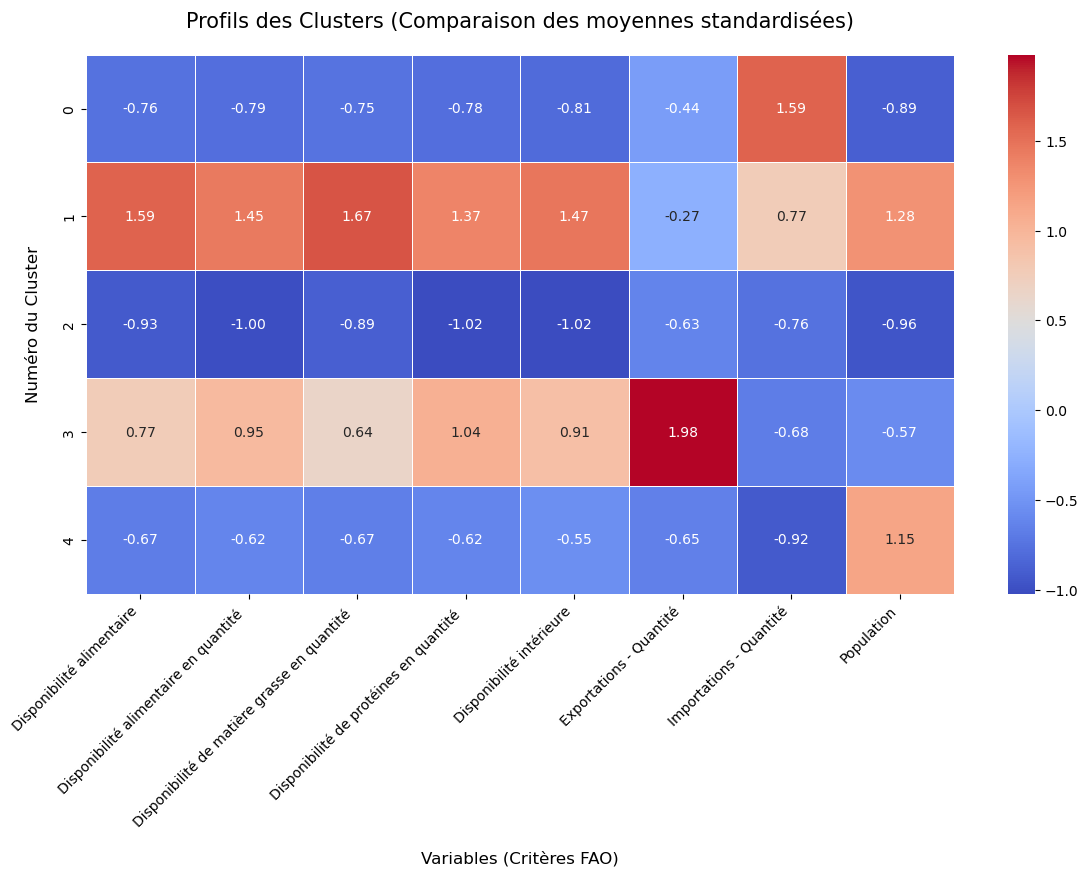

In [32]:
# 1. Calcul des moyennes par cluster (Centroïdes)
centroid_analysis = df_final.groupby('Cluster_KMeans').mean()

# 2. Standardisation pour la visualisation (pour avoir une échelle comparable de -2 à 2)
# On remet immédiatement le résultat dans un DataFrame avec les bons noms de colonnes et d'index
scaler_visu = StandardScaler()
centroid_scaled = pd.DataFrame(
    scaler_visu.fit_transform(centroid_analysis), 
    columns=centroid_analysis.columns, 
    index=centroid_analysis.index
)

# 3. Création de la Heatmap avec titres et labels
plt.figure(figsize=(14, 7)) # J'ai un peu agrandi pour la lisibilité

sns.heatmap(
    centroid_scaled, 
    annot=True,          # Affiche les valeurs dans les cases
    cmap='coolwarm',     # Bleu = Faible, Rouge = Élevé
    fmt=".2f",           # 2 chiffres après la virgule
    linewidths=.5        # Petites lignes blanches pour séparer
)

# Ajout des noms des axes (C'est ici que ça se joue !)
plt.title("Profils des Clusters (Comparaison des moyennes standardisées)", fontsize=15, pad=20)
plt.xlabel("Variables (Critères FAO)", fontsize=12, labelpad=15)
plt.ylabel("Numéro du Cluster", fontsize=12, labelpad=15)

# Rotation des étiquettes de l'axe X pour qu'elles ne se chevauchent pas
plt.xticks(rotation=45, ha='right') 

plt.show()

In [33]:
# On récupère la liste des numéros de clusters (0, 1, 2...)
clusters = sorted(df_final['Cluster_KMeans'].unique())

for cluster_id in clusters:
    print(f"\n--- CLUSTER {cluster_id} ---")
    
    # On filtre les pays qui appartiennent à ce cluster
    # Si 'Zone' est une colonne normale :
    pays_du_cluster = df_final[df_final['Cluster_KMeans'] == cluster_id]['Zone'].values
    
    # Si 'Zone' est dans l'index (si tu as fait set_index plus tôt sur df_final) :
    # pays_du_cluster = df_final[df_final['Cluster_KMeans'] == cluster_id].index.tolist()
    
    # On affiche le nombre de pays et la liste
    print(f"Nombre de pays : {len(pays_du_cluster)}")
    print(f"Liste : {', '.join(pays_du_cluster)}")


--- CLUSTER 0 ---
Nombre de pays : 12
Liste : Afrique du Sud, Allemagne, Arabie saoudite, Chine - RAS de Hong-Kong, France, Fédération de Russie, Iraq, Japon, Mexique, Pays-Bas, Royaume-Uni de Grande-Bretagne et d'Irlande du Nord, Émirats arabes unis

--- CLUSTER 1 ---
Nombre de pays : 1
Liste : Chine, continentale

--- CLUSTER 2 ---
Nombre de pays : 156
Liste : Afghanistan, Albanie, Algérie, Angola, Antigua-et-Barbuda, Argentine, Arménie, Australie, Autriche, Azerbaïdjan, Bahamas, Bangladesh, Barbade, Belgique, Belize, Bolivie (État plurinational de), Bosnie-Herzégovine, Botswana, Bulgarie, Burkina Faso, Bélarus, Bénin, Cabo Verde, Cambodge, Cameroun, Canada, Chili, Chine - RAS de Macao, Chine, Taiwan Province de, Chypre, Colombie, Congo, Costa Rica, Croatie, Cuba, Côte d'Ivoire, Danemark, Djibouti, Dominique, El Salvador, Espagne, Estonie, Eswatini, Fidji, Finlande, Gabon, Gambie, Ghana, Grenade, Grèce, Guatemala, Guinée, Guinée-Bissau, Guyana, Géorgie, Haïti, Honduras, Hongrie, Ind

## On retire USA, Brésil,Chine, Inde, Fédération de Russie,

In [34]:
# Liste des pays à retirer (Attention à l'orthographe exacte présente dans ta colonne 'Zone')
pays_a_retirer = ["Chine, continentale", "Brésil", "États-Unis d'Amérique","Inde"]

# On filtre le dataframe pour ne garder QUE ce qui n'est PAS (~) dans la liste
df_filtered = df_final[~df_final['Zone'].isin(pays_a_retirer)].copy()

# Vérification
print(f"Dimensions avant : {df_final.shape}")
print(f"Dimensions après : {df_filtered.shape}")

Dimensions avant : (172, 10)
Dimensions après : (168, 10)


In [35]:
df_final.head()

,Zone,Disponibilité alimentaire,Disponibilité alimentaire en quantité,Disponibilité de matière grasse en quantité,Disponibilité de protéines en quantité,Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Population,Cluster_KMeans
17,Afghanistan,6.624041e+10,5.553305e+07,4.371867e+09,7.153964e+09,57000.0,0.0,29.0,36296113.0,2
36,Afrique du Sud,2.975624e+12,2.034678e+09,1.924792e+11,2.936088e+11,2118000.0,63000.0,514.0,57009756.0,0
55,Albanie,8.948134e+10,4.718500e+07,6.790055e+09,6.590038e+09,47000.0,0.0,38.0,2884169.0,2
74,Algérie,3.323552e+11,2.640630e+08,2.266058e+10,2.976090e+10,277000.0,0.0,2.0,41389189.0,2
93,Allemagne,2.142093e+12,1.609359e+09,1.255085e+11,2.401557e+11,1739000.0,646000.0,842.0,82658409.0,0


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than availabl

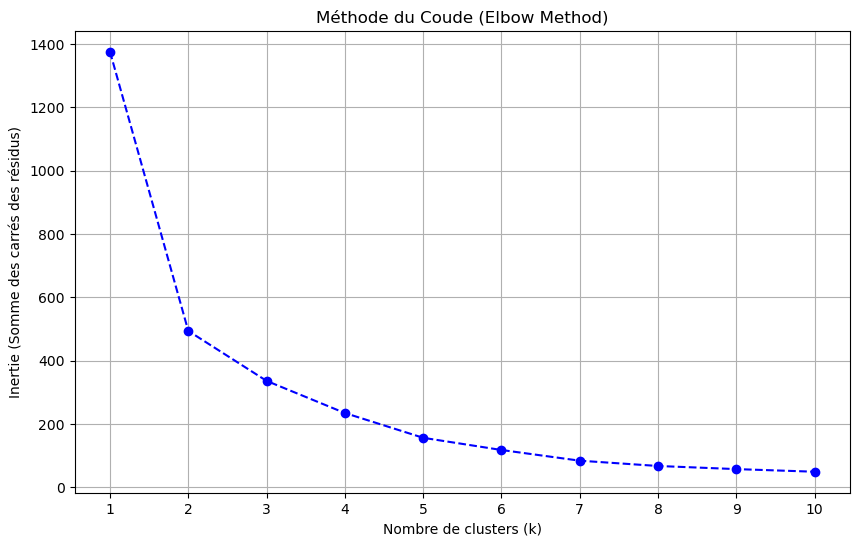

In [36]:
# 1. Calcul de l'inertie pour différents nombres de clusters (de 1 à 10)
intertia = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    intertia.append(model.inertia_)

# 2. Traçage du graphique du coude
plt.figure(figsize=(10, 6))
plt.plot(K_range, intertia, marker='o', linestyle='--', color='b')

# Mise en forme
plt.title('Méthode du Coude (Elbow Method)')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie (Somme des carrés des résidus)')
plt.xticks(K_range)
plt.grid(True)

# Optionnel : marquer l'endroit du coude si tu l'as déjà identifié visuellement (ex: k=5)
# plt.axvline(x=5, color='r', linestyle='-') 

plt.show()

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import scipy.cluster.hierarchy as sch

# --- ÉTAPE 1 : FILTRAGE ET PRÉPARATION ---
print("1. Filtrage des données...")
pays_a_retirer = ["Chine, continentale", "Brésil", "États-Unis d'Amérique","Inde","Fédération de Russie", "Mexique"]

# On garde uniquement les pays qui NE sont PAS (~) dans la liste
df_filtered = df_final[~df_final['Zone'].isin(pays_a_retirer)].copy()

# Mise en place de l'index
data_clustering = df_filtered.set_index('Zone')

# Centrage et Réduction (Indispensable après avoir retiré des pays)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data_clustering)
df_scaled = pd.DataFrame(X_scaled, columns=data_clustering.columns, index=data_clustering.index)
print(f"Nouveau jeu de données prêt : {df_scaled.shape[0]} pays restants.")





1. Filtrage des données...
Nouveau jeu de données prêt : 166 pays restants.


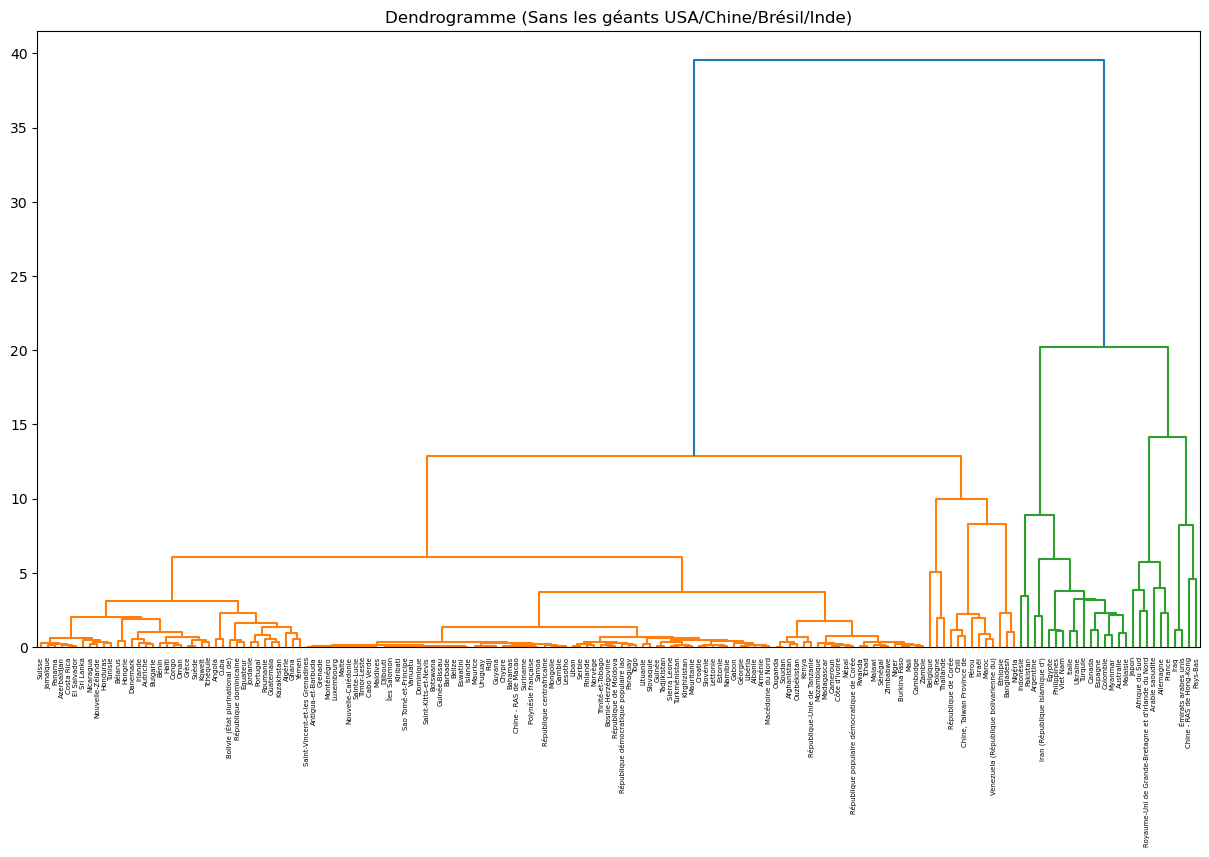

In [38]:
# --- ÉTAPE 2 : CAH (DENDROGRAMME) ---
plt.figure(figsize=(15, 8))
plt.title("Dendrogramme (Sans les géants USA/Chine/Brésil/Inde)")
Z = sch.linkage(X_scaled, method='ward')
dendrogram = sch.dendrogram(Z, labels=df_scaled.index, leaf_rotation=90)
plt.show()


In [39]:
# --- ÉTAPE 3 : K-MEANS ---
# Note : Regarde le dendrogramme ci-dessus pour ajuster le nombre de clusters (k) si besoin.
k = 4  # Tu peux changer ce chiffre selon ta lecture du dendrogramme
print(f"Lancement du K-Means avec {k} clusters...")

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Ajout du cluster au dataframe filtré
df_filtered['Cluster'] = kmeans.labels_

Lancement du K-Means avec 4 clusters...


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


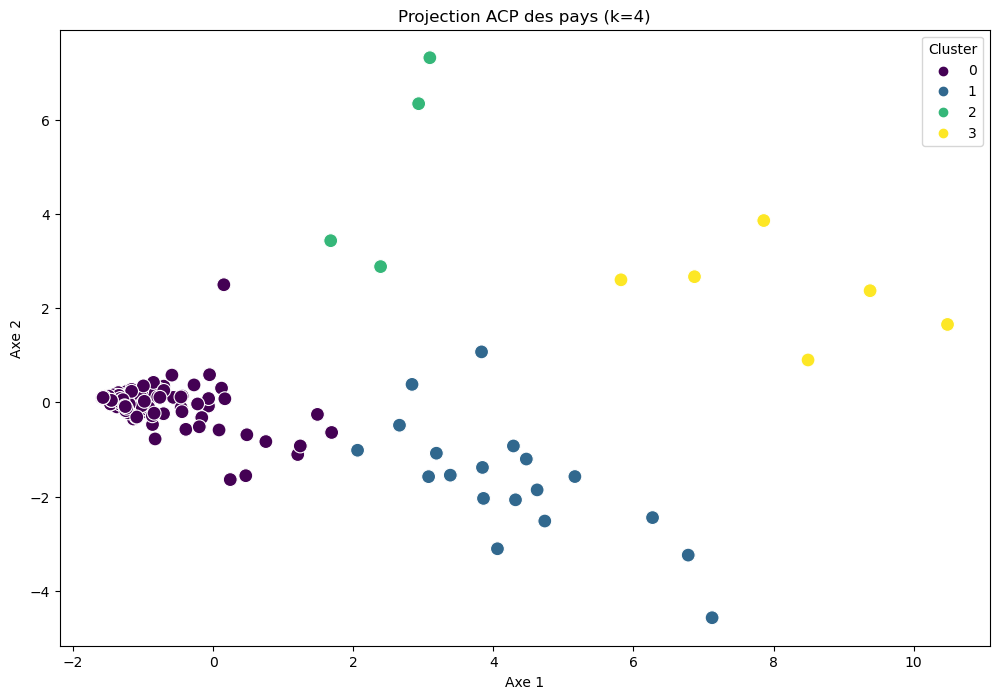

In [40]:
# --- ÉTAPE 4 : VISUALISATION ACP (PCA) ---
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(components, columns=['PC1', 'PC2'], index=data_clustering.index)
df_pca['Cluster'] = kmeans.labels_

plt.figure(figsize=(12, 8))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=100)
plt.title(f"Projection ACP des pays (k={k})")
plt.xlabel("Axe 1")
plt.ylabel("Axe 2")
plt.show()

C:\Users\lapoi\AppData\Local\Temp\ipykernel_21680\2738760839.py:3: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  centroid = df_filtered.groupby('Cluster').mean()


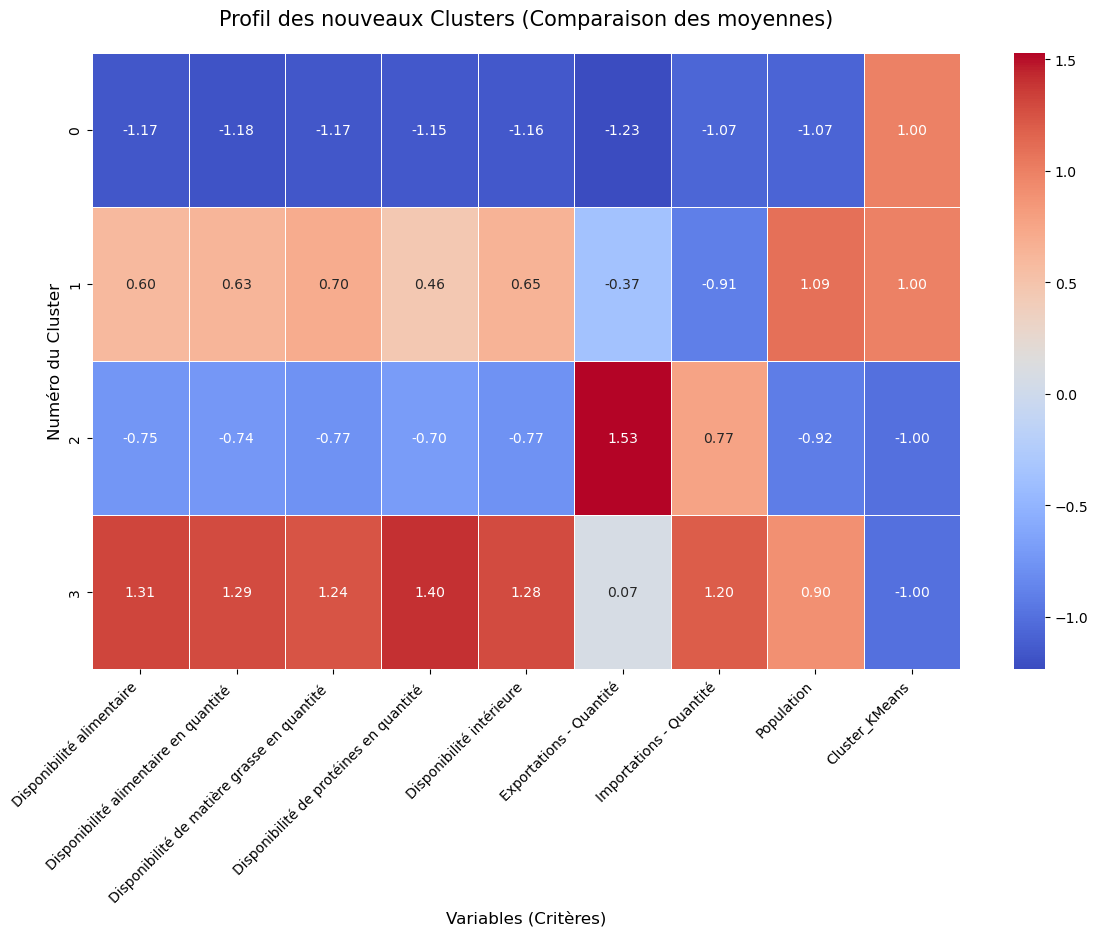

In [41]:
# --- ÉTAPE 5 : HEATMAP DES CENTROÏDES (PROFIL DES GROUPES) ---
# Calcul des moyennes par cluster
centroid = df_filtered.groupby('Cluster').mean()

# Standardisation juste pour la couleur de la heatmap (lisibilité)
scaler_visu = StandardScaler()
centroid_scaled = pd.DataFrame(scaler_visu.fit_transform(centroid), 
                               columns=centroid.columns, 
                               index=centroid.index)

plt.figure(figsize=(14, 8))
sns.heatmap(centroid_scaled, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Profil des nouveaux Clusters (Comparaison des moyennes)", fontsize=15, pad=20)
plt.xlabel("Variables (Critères)", fontsize=12)
plt.ylabel("Numéro du Cluster", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

In [42]:
# --- ÉTAPE 6 : LISTE DES PAYS PAR CLUSTER ---
for i in range(k):
    pays = df_filtered[df_filtered['Cluster'] == i]['Zone'].values
    print(f"\nCluster {i} ({len(pays)} pays) :")
    print(", ".join(pays[:15]) + ("..." if len(pays) > 15 else "")) # Affiche les 15 premiers pour ne pas spammer


Cluster 0 (137 pays) :
Afghanistan, Albanie, Algérie, Angola, Antigua-et-Barbuda, Arménie, Autriche, Azerbaïdjan, Bahamas, Bangladesh, Barbade, Belgique, Belize, Bolivie (État plurinational de), Bosnie-Herzégovine...

Cluster 1 (19 pays) :
Argentine, Australie, Canada, Colombie, Espagne, Indonésie, Iran (République islamique d'), Italie, Malaisie, Myanmar, Pakistan, Philippines, Pologne, République de Corée, Thaïlande...

Cluster 2 (4 pays) :
Chine - RAS de Hong-Kong, Iraq, Pays-Bas, Émirats arabes unis

Cluster 3 (6 pays) :
Afrique du Sud, Allemagne, Arabie saoudite, France, Japon, Royaume-Uni de Grande-Bretagne et d'Irlande du Nord


### Analyse sur uniquement "Chine, continentale", "Brésil", "États-Unis d'Amérique","Inde","Fédération de Russie", "Mexique" 

In [43]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Sélection des pays cibles
pays_cibles = [
    "Chine, continentale", "Brésil", "États-Unis d'Amérique", 
    "Inde", "Fédération de Russie", "Mexique"
]

# On filtre pour ne garder que ceux qui sont DANS (isin) la liste
df_focus = df_final[df_final['Zone'].isin(pays_cibles)].copy()

# Mise en index de la zone pour l'affichage
data_focus = df_focus.set_index('Zone')

# 2. Centrage et Réduction
scaler = StandardScaler()
X_focus_scaled = scaler.fit_transform(data_focus)

# DataFrame propre pour la suite
df_focus_scaled = pd.DataFrame(X_focus_scaled, columns=data_focus.columns, index=data_focus.index)

print("Données prêtes pour les 6 pays sélectionnés.")
print(df_focus_scaled.head(6))

Données prêtes pour les 6 pays sélectionnés.
                       Disponibilité alimentaire  \
Zone                                               
Brésil                                  0.098122   
Chine, continentale                     1.524665   
Fédération de Russie                   -0.840337   
Inde                                   -1.038762   
Mexique                                -0.833023   
États-Unis d'Amérique                   1.089334   

                       Disponibilité alimentaire en quantité   \
Zone                                                            
Brésil                                               0.073161   
Chine, continentale                                  1.276020   
Fédération de Russie                                -0.800189   
Inde                                                -1.045367   
Mexique                                             -0.872110   
États-Unis d'Amérique                                1.368484   

                 

###  Bloc 2 : Classification Ascendante Hiérarchique (CAH)

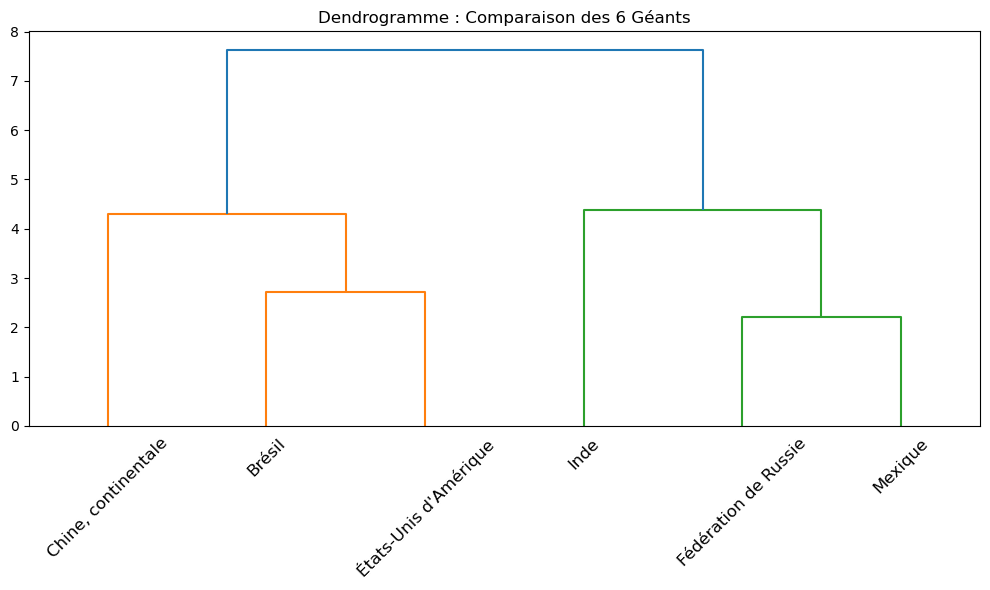

In [44]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.title("Dendrogramme : Comparaison des 6 Géants")

# Calcul des liens (Ward minimise la variance au sein des groupes)
Z = sch.linkage(X_focus_scaled, method='ward')

# Affichage
dendrogram = sch.dendrogram(Z, labels=df_focus_scaled.index, leaf_rotation=45)
plt.tight_layout()
plt.show()

### kmeans et ACP

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


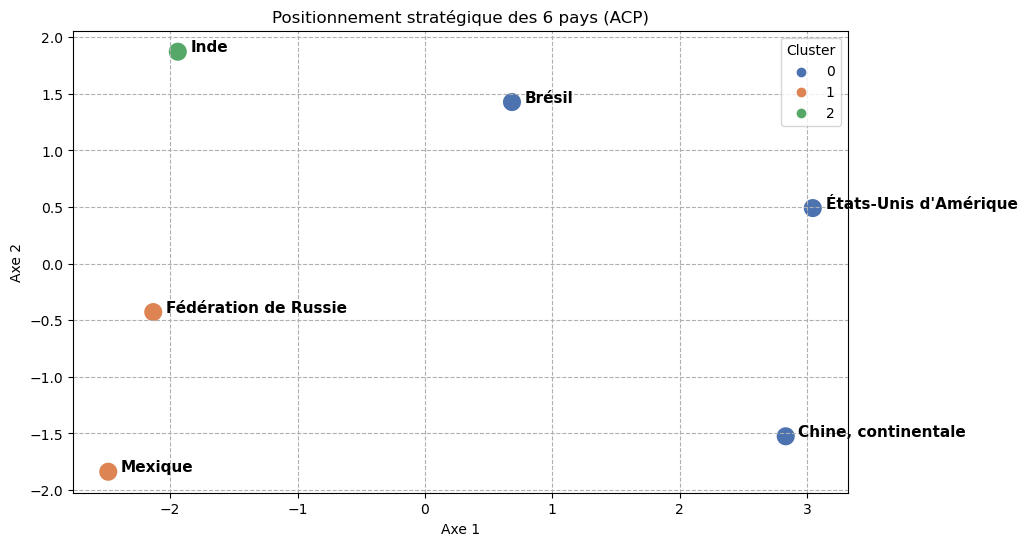

In [45]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import seaborn as sns

# 1. K-Means (On force 3 groupes pour voir les différences marquées)
k = 3
kmeans_focus = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans_focus.fit(X_focus_scaled)

# On stocke les résultats
df_focus['Cluster'] = kmeans_focus.labels_

# 2. ACP pour visualiser en 2D
pca = PCA(n_components=2)
components = pca.fit_transform(X_focus_scaled)
df_pca_focus = pd.DataFrame(components, columns=['PC1', 'PC2'], index=data_focus.index)
df_pca_focus['Cluster'] = kmeans_focus.labels_

# 3. Graphique
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca_focus, palette='deep', s=200)

# Ajout des noms des pays directement sur les points
for i in range(df_pca_focus.shape[0]):
    plt.text(df_pca_focus.PC1[i]+0.1, df_pca_focus.PC2[i], df_pca_focus.index[i], fontsize=11, weight='bold')

plt.title("Positionnement stratégique des 6 pays (ACP)")
plt.xlabel("Axe 1")
plt.ylabel("Axe 2")
plt.grid(True, linestyle='--', alpha=1)
plt.show()

### heatmap

C:\Users\lapoi\AppData\Local\Temp\ipykernel_21680\658035519.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  centroid_focus = df_focus.groupby('Cluster').mean()


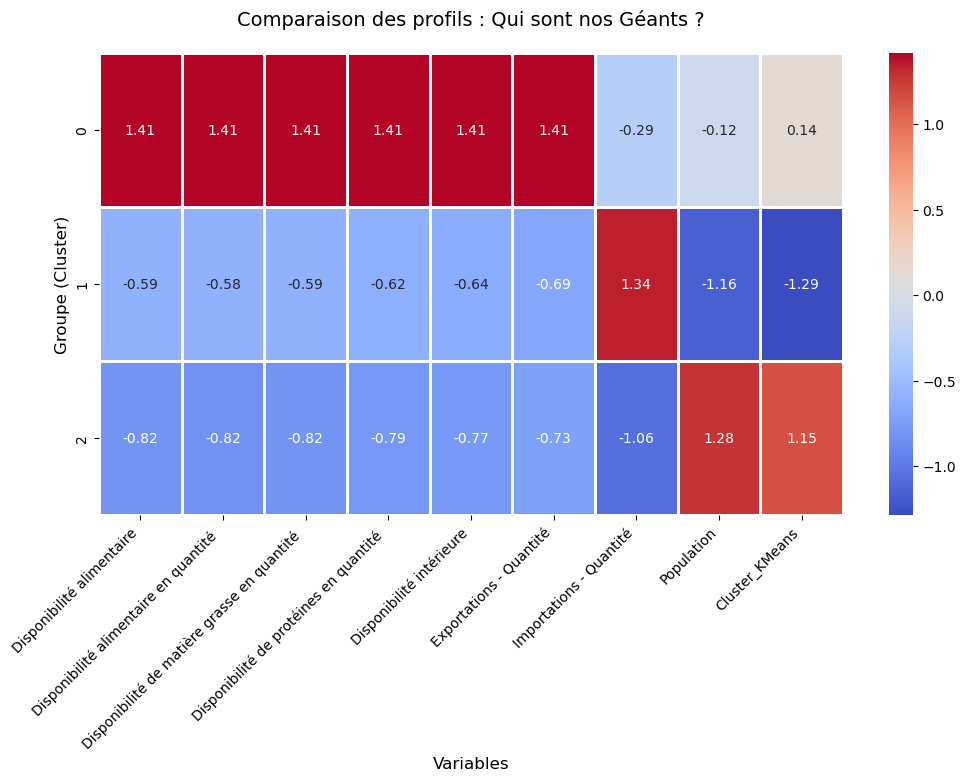

Cluster 0 : Brésil, Chine, continentale, États-Unis d'Amérique
Cluster 1 : Fédération de Russie, Mexique
Cluster 2 : Inde


In [46]:
# 1. Calcul des moyennes par cluster
centroid_focus = df_focus.groupby('Cluster').mean()

# 2. Standardisation pour les couleurs (Heatmap)
scaler_visu = StandardScaler()
centroid_focus_scaled = pd.DataFrame(
    scaler_visu.fit_transform(centroid_focus), 
    columns=centroid_focus.columns, 
    index=centroid_focus.index
)

# 3. Affichage
plt.figure(figsize=(12, 6))
sns.heatmap(
    centroid_focus_scaled, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=1, 
    linecolor='white'
)

plt.title("Comparaison des profils : Qui sont nos Géants ?", fontsize=14, pad=20)
plt.xlabel("Variables", fontsize=12)
plt.ylabel("Groupe (Cluster)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.show()

# 4. Affichage simple des groupes pour lecture immédiate
for i in range(k):
    pays = df_focus[df_focus['Cluster'] == i]['Zone'].values
    print(f"Cluster {i} : {', '.join(pays)}")